In [29]:
import pandas as pd
import matplotlib.pyplot as plt

In [13]:
df=pd.read_csv("data/train.csv")
df.head()

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND,CARRIER_HISTORICAL,DEP_AIRPORT_HIST,DAY_HISTORICAL,DEP_BLOCK_HIST
0,7,7,0,1500-1559,3,3,26,160,American Airlines Inc.,19534,...,Chicago O'Hare International,0.00,0.0,0.0,95.0,4.25,0.237709,0.273236,0.222538,0.255479
1,4,1,0,1300-1359,4,4,63,50,SkyWest Airlines Inc.,18788,...,El Paso International,0.00,0.0,0.0,71.0,11.41,0.154651,0.121849,0.237972,0.197503
2,11,4,0,0001-0559,2,1,3,76,American Eagle Airlines Inc.,1148,...,NONE,0.00,0.0,0.0,54.0,0.45,0.117559,0.187867,0.139886,0.060327
3,3,2,0,1500-1559,7,5,14,143,Southwest Airlines Co.,7612,...,San Jose International,0.00,0.0,0.0,64.0,8.05,0.204389,0.141446,0.132868,0.202037
4,7,3,0,0800-0859,1,2,85,50,American Eagle Airlines Inc.,29376,...,Cincinnati/Northern Kentucky International,0.01,0.0,0.0,94.0,10.51,0.203263,0.193761,0.203027,0.113050


Select relevant variables

In [19]:
df_train = df[["MONTH", "DAY_OF_WEEK", "DEP_DEL15", "CONCURRENT_FLIGHTS", "CARRIER_NAME", "PRCP", "AWND"]]
df_train=df_train.rename(columns={"DEP_DEL15": "DELAY", "AWND":"WIND"})
print(f"Number of observations: {len(df_train)}")
df_train.head()

Number of observations: 4542343


,MONTH,DAY_OF_WEEK,DELAY,CONCURRENT_FLIGHTS,CARRIER_NAME,PRCP,WIND
0,7,7,0,26,American Airlines Inc.,0.00,4.25
1,4,1,0,63,SkyWest Airlines Inc.,0.00,11.41
2,11,4,0,3,American Eagle Airlines Inc.,0.00,0.45
3,3,2,0,14,Southwest Airlines Co.,0.00,8.05
4,7,3,0,85,American Eagle Airlines Inc.,0.01,10.51


In [25]:
print(df_train.isna().sum())

MONTH                 0
DAY_OF_WEEK           0
DELAY                 0
CONCURRENT_FLIGHTS    0
CARRIER_NAME          0
PRCP                  0
WIND                  0
dtype: int64


### Categorical Variables

In [24]:
df_train["MONTH"].value_counts().sort_index()

MONTH
1     351390
2     315785
3     387505
4     373800
5     390479
6     389812
7     404984
8     406093
9     370721
10    393106
11    372259
12    386409
Name: count, dtype: int64

In [26]:
df_train["DAY_OF_WEEK"].value_counts().sort_index()

DAY_OF_WEEK
1    676815
2    662339
3    656193
4    669146
5    678895
6    552926
7    646029
Name: count, dtype: int64

Classes are not balanced

In [27]:
df_train["DELAY"].value_counts().sort_index()

DELAY
0    3683185
1     859158
Name: count, dtype: int64

In [32]:
df_train["CARRIER_NAME"].value_counts()

CARRIER_NAME
Southwest Airlines Co.          907076
Delta Air Lines Inc.            657062
American Airlines Inc.          632771
United Air Lines Inc.           420624
SkyWest Airlines Inc.           409126
Midwest Airline, Inc.           210298
JetBlue Airways                 188402
Alaska Airlines Inc.            167595
American Eagle Airlines Inc.    160390
Comair Inc.                     153365
Endeavor Air Inc.               142498
Spirit Air Lines                132678
Mesa Airlines Inc.              124171
Frontier Airlines Inc.           84970
Atlantic Southeast Airlines      69161
Hawaiian Airlines Inc.           52444
Allegiant Air                    29712
Name: count, dtype: int64

### Non Categorical Variables

Looks Half Normal

Maximum value of concurrent flights: 109
Minimum value of concurrent flights: 1


(array([599940., 636825., 593137., 433025., 447092., 457009., 230487.,
        216521., 148400., 120230., 172017., 129255., 111502.,  69312.,
         70553.,  66068.,  30085.,   6809.,   1162.,   2914.]),
 array([  1. ,   6.4,  11.8,  17.2,  22.6,  28. ,  33.4,  38.8,  44.2,
         49.6,  55. ,  60.4,  65.8,  71.2,  76.6,  82. ,  87.4,  92.8,
         98.2, 103.6, 109. ]),
 <BarContainer object of 20 artists>)

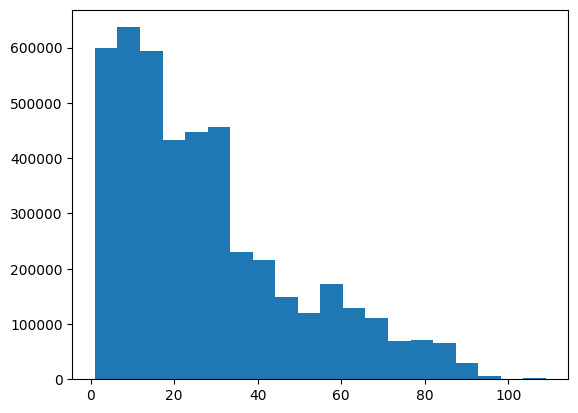

In [30]:
print(f"Maximum value of concurrent flights: {df_train["CONCURRENT_FLIGHTS"].max()}")
print(f"Minimum value of concurrent flights: {df_train["CONCURRENT_FLIGHTS"].min()}")

cflights=df_train["CONCURRENT_FLIGHTS"].values
plt.hist(cflights, bins=20)

Maximum value of precipitation: 11.63
Minimum value of precipitation: 0.0


(array([4.294207e+06, 1.579360e+05, 5.825700e+04, 1.841400e+04,
        6.946000e+03, 2.534000e+03, 1.358000e+03, 9.050000e+02,
        2.590000e+02, 0.000000e+00, 1.200000e+02, 0.000000e+00,
        8.780000e+02, 0.000000e+00, 0.000000e+00, 0.000000e+00,
        0.000000e+00, 1.710000e+02, 0.000000e+00, 3.580000e+02]),
 array([ 0.    ,  0.5815,  1.163 ,  1.7445,  2.326 ,  2.9075,  3.489 ,
         4.0705,  4.652 ,  5.2335,  5.815 ,  6.3965,  6.978 ,  7.5595,
         8.141 ,  8.7225,  9.304 ,  9.8855, 10.467 , 11.0485, 11.63  ]),
 <BarContainer object of 20 artists>)

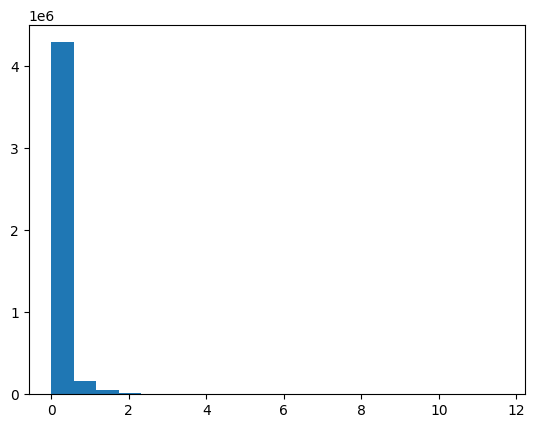

In [33]:
print(f"Maximum value of precipitation: {df_train["PRCP"].max()}")
print(f"Minimum value of precipitation: {df_train["PRCP"].min()}")

prcp=df_train["PRCP"].values
plt.hist(prcp, bins=20)

Maximum value of wind: 33.78
Minimum value of wind: 0.0


(array([1.48870e+04, 1.98091e+05, 5.77473e+05, 9.40026e+05, 8.65017e+05,
        7.49674e+05, 4.70822e+05, 3.26904e+05, 1.69936e+05, 1.13152e+05,
        5.87890e+04, 2.73220e+04, 1.69360e+04, 6.94800e+03, 3.43000e+03,
        1.65800e+03, 1.03100e+03, 4.40000e+01, 6.20000e+01, 1.41000e+02]),
 array([ 0.   ,  1.689,  3.378,  5.067,  6.756,  8.445, 10.134, 11.823,
        13.512, 15.201, 16.89 , 18.579, 20.268, 21.957, 23.646, 25.335,
        27.024, 28.713, 30.402, 32.091, 33.78 ]),
 <BarContainer object of 20 artists>)

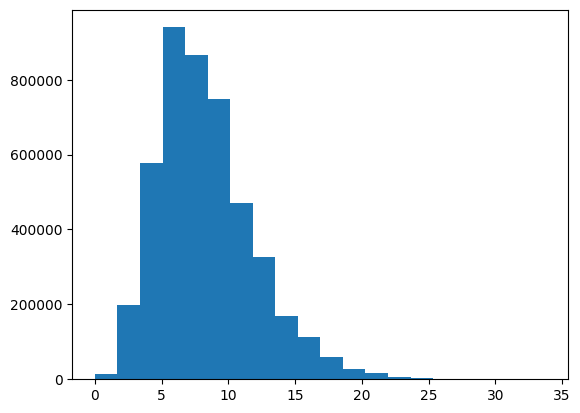

In [36]:
print(f"Maximum value of wind: {df_train["WIND"].max()}")
print(f"Minimum value of wind: {df_train["WIND"].min()}")

wind=df_train["WIND"].values
plt.hist(wind, bins=20)